# Лабораторная работа 1  
### ПРЕДВАРИТЕЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

ЗАДАЧИ ИССЛЕДОВАНИЯ
1. Исследовать основные описательные статистики для каждого коэффициента
(минимум, максимум, среднее, медиана, стандартное отклонение) с целью ознакомления с
особенностями данных и их распределением.
2. Провести графический анализ данных с целью анализа их распределения на
основе построения гистограмм.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [49]:
df = pd.read_spss(r'.\data\data_lab1_start.sav')
df.head(3)
df.describe()



,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,...,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,2.002089,0.238018,0.825098,0.038115,0.335777,0.346330,0.238031,0.174212,0.655964,...,1.351127,1.201444,9.944428,13.504512,2.149889,201.286497,0.054974,0.079206,0.065179,8.000000
std,2556.406482,1.690052,0.517697,0.918292,0.625155,0.360196,0.198008,0.213094,0.223266,0.195774,...,0.596442,0.700291,7.636115,13.384226,2.817287,2260.459197,0.110704,0.094002,0.146802,2.000371
min,10.000000,0.248322,0.000000,0.008329,-4.569874,-2.599123,0.009944,0.000000,0.000000,0.053766,...,0.230067,0.033180,0.220451,0.347459,0.000000,0.447730,-0.975133,-0.321271,-2.670820,5.000000
25%,229.500000,1.097990,0.017088,0.317674,-0.181377,0.154884,0.185165,0.062932,0.001073,0.522272,...,1.071357,0.672567,4.598417,5.980288,0.734275,10.060489,0.023797,0.017260,0.004226,6.000000
50%,473.000000,1.473859,0.055551,0.538349,0.148620,0.367201,0.319908,0.185185,0.075676,0.681890,...,1.180362,1.106136,8.169934,9.851228,1.235572,20.099094,0.059466,0.056022,0.044154,8.000000
75%,1128.500000,2.238232,0.211538,0.941372,0.422199,0.573384,0.479741,0.361182,0.268773,0.817227,...,1.356088,1.591163,13.316773,16.690873,2.384732,48.951216,0.103877,0.123064,0.119201,10.000000
max,28650.000000,18.020148,7.029135,11.187699,0.935935,0.944507,1.083702,1.000000,1.000000,0.990056,...,10.809042,4.982852,68.830441,195.041667,31.559748,104151.000000,0.860892,0.635036,0.836596,11.000000


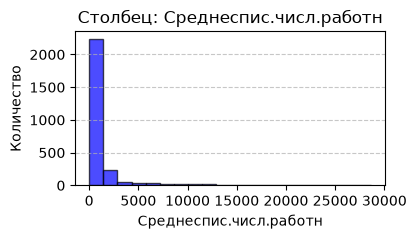

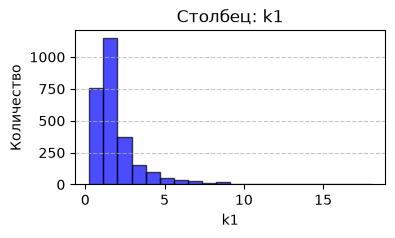

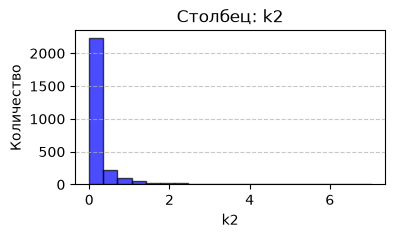

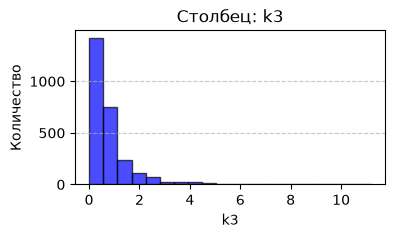

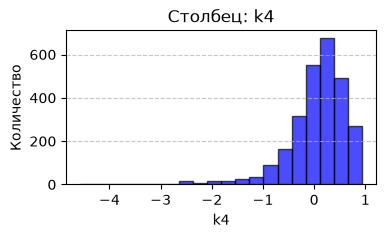

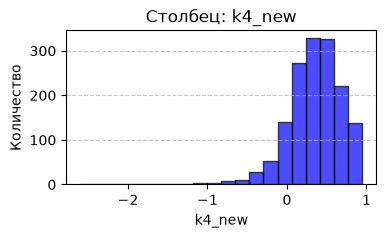

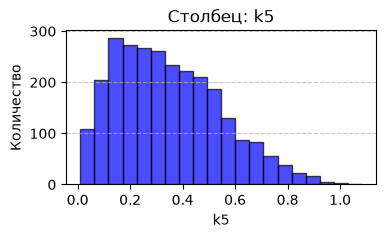

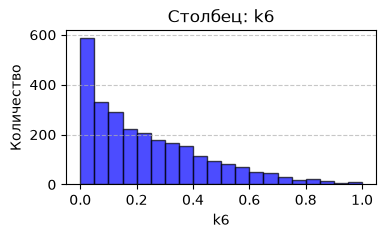

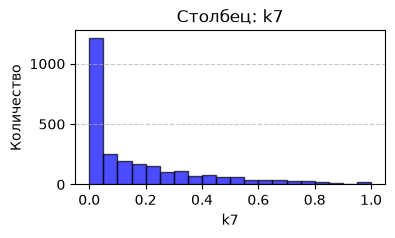

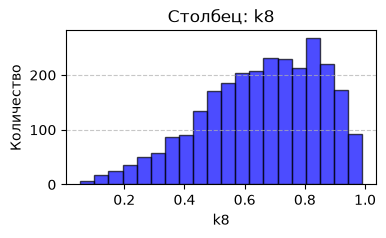

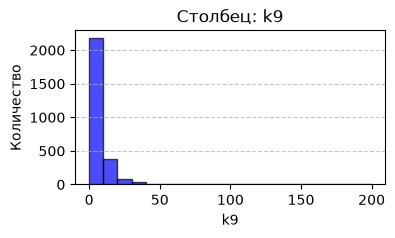

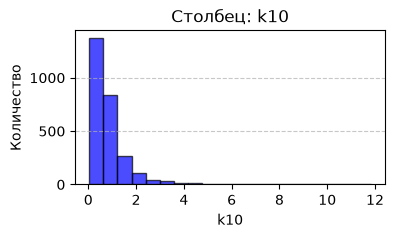

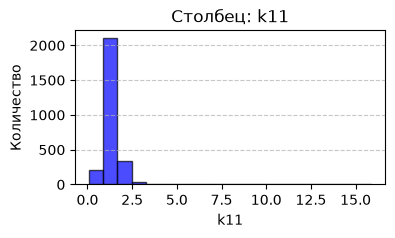

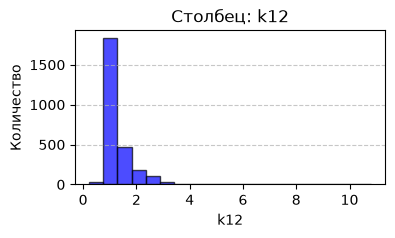

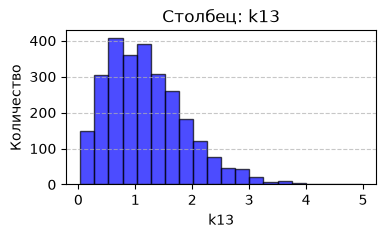

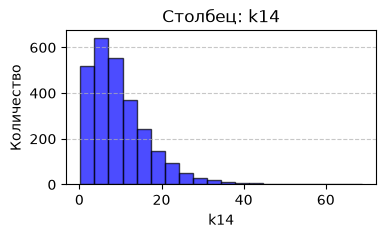

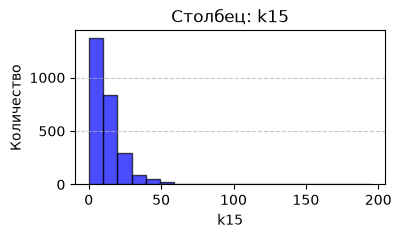

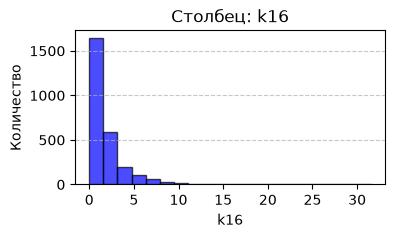

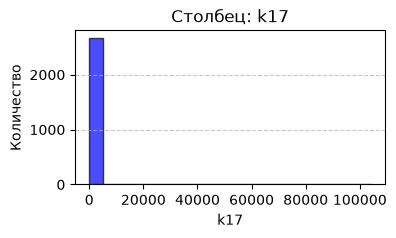

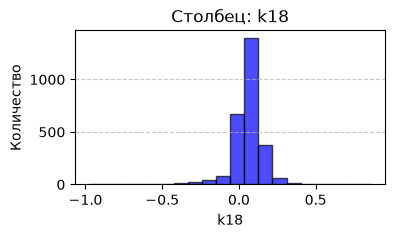

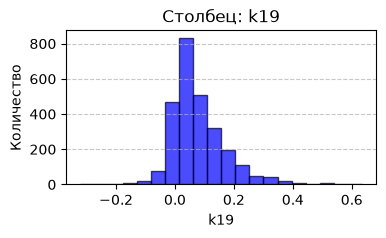

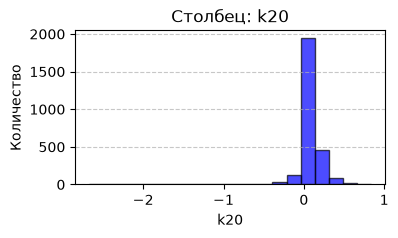

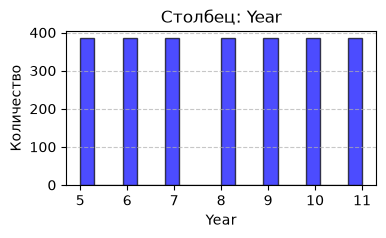

In [50]:
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    plt.figure(figsize=(4,2))
    plt.hist(df[col].dropna(), bins=20, color='blue', edgecolor='black', alpha=0.7)
    plt.title(f"Столбец: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.grid(axis='y', linestyle='--', alpha = 0.7)
    plt.show()

Похожим на нормальное распределение являются коэффициенты К18-К20  

ЗАДАЧИ ИССЛЕДОВАНИЯ
1. Провести графический анализ данных с целью выявления аномальных
наблюдений на основе построения ящичных диаграмм.
2. На основании условия ниже или «правила шести сигм» определить экстремальные
наблюдения в выборке. Множитель в это условие подобрать таким образом, чтобы
экстремальными признавалось не более 5-8% наблюдений
3. Провести цензурирование и нормировку данных.

$$[x_{med} - 5.2 \cdot x_{mad}, \ x_{med} + 5.2 \cdot x_{mad}]$$

где:
* $x_{med}$ — медиана выборки $\{x_i\}$
* $x_{mad}$ — медиана выборки $\{|x_i - x_{med}|\} \ (i = \overline{1, n})$ абсолютных отклонений от $x_{med}$


Интервал допустимых значений (границы фильтрации) рассчитывается как:

$$[x_{med} - 5.2 \cdot MAD_{left}, \ x_{med} + 5.2 \cdot MAD_{right}]$$

где компоненты формулы определяются следующим образом:

1. **Медиана всей выборки:**
$$x_{med} = \text{median}(\{x_i\}_{i=1}^n)$$

2. **Левое медианное абсолютное отклонение ($MAD_{left}$):**
$$MAD_{left} = \text{median}(\{|x_i - x_{med}|\}) \quad \text{при условии } x_i \le x_{med}$$

3. **Правое медианное абсолютное отклонение ($MAD_{right}$):**
$$MAD_{right} = \text{median}(\{|x_i - x_{med}|\}) \quad \text{при условии } x_i \ge x_{med}$$

Наблюдение $x_i$ признается экстремальным (выбросом), если оно выходит за пределы рассчитанного интервала.


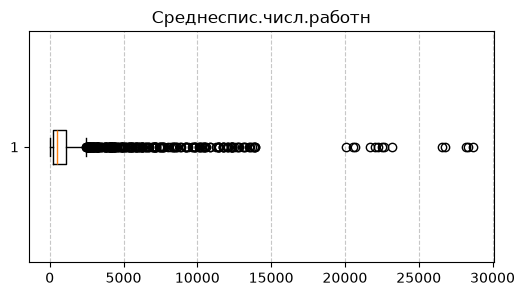

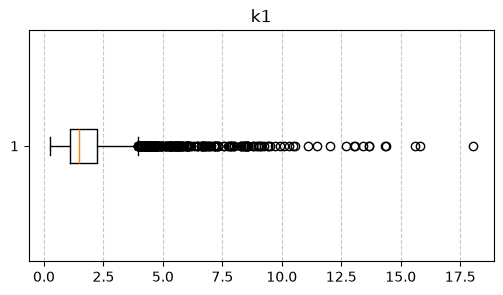

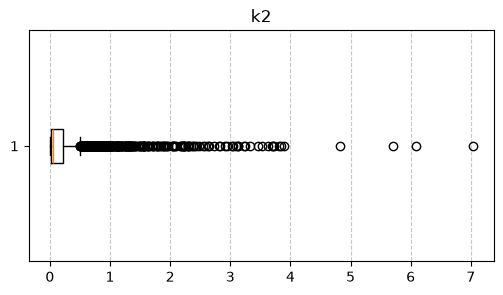

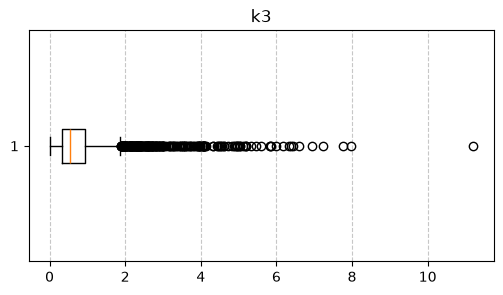

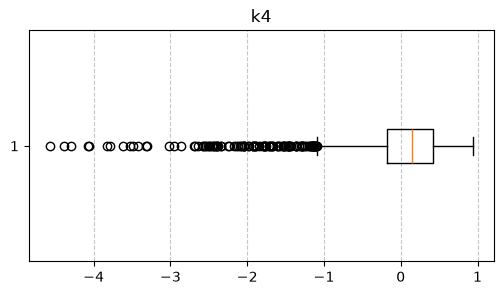

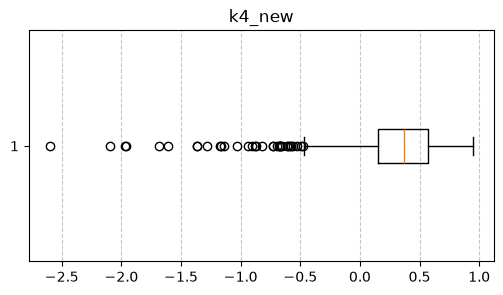

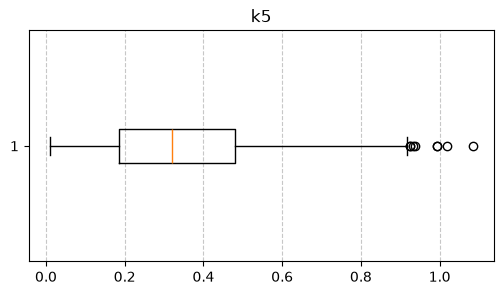

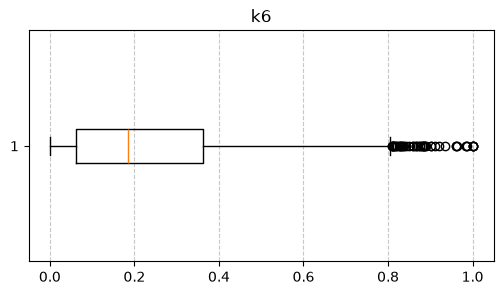

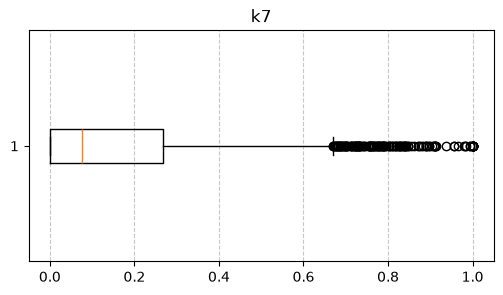

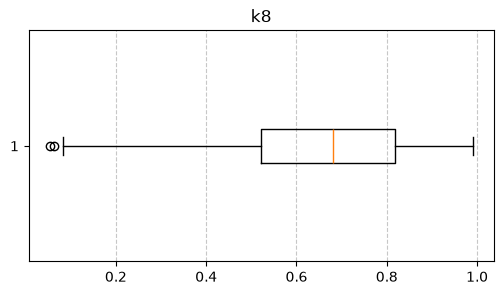

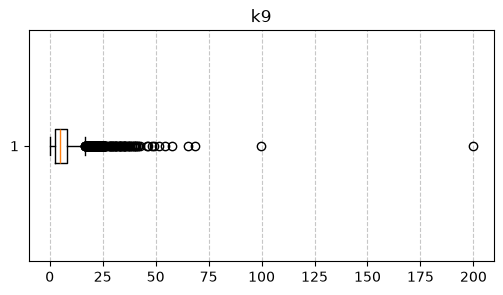

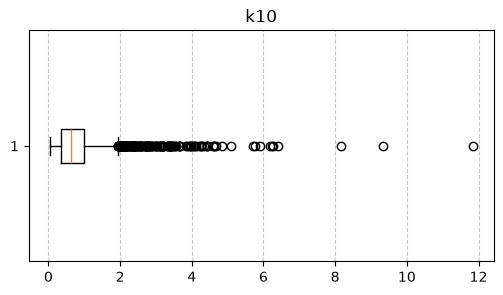

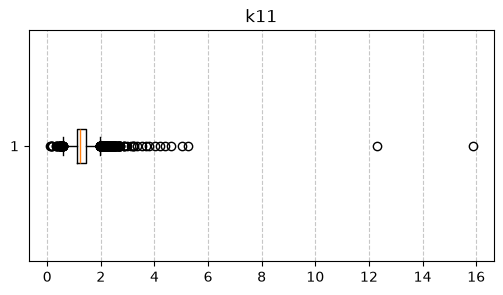

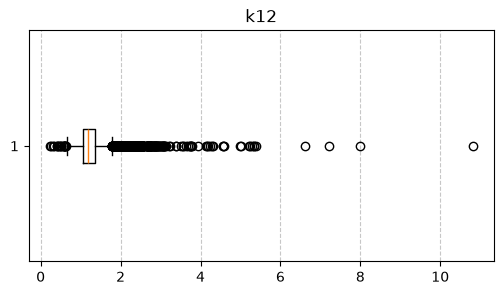

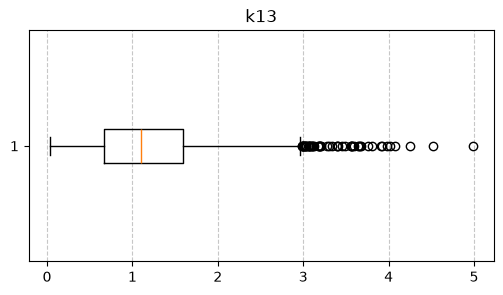

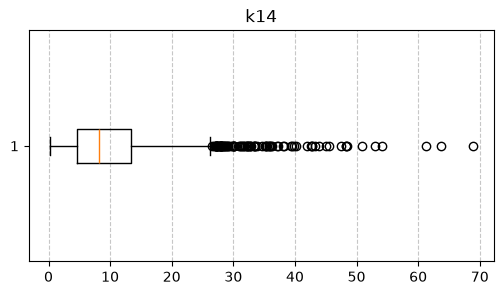

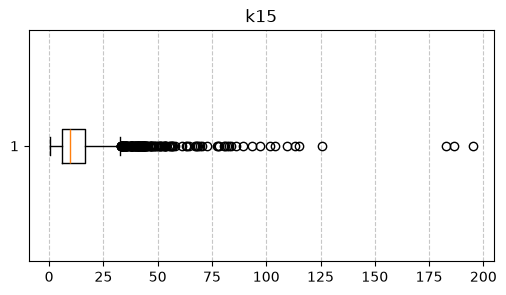

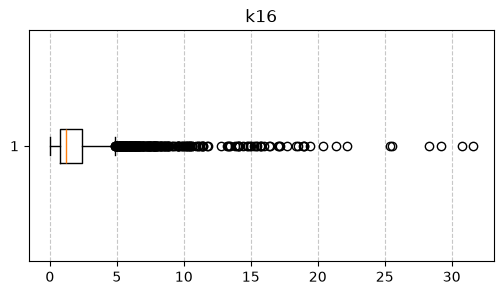

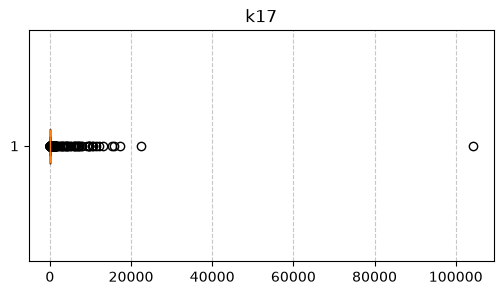

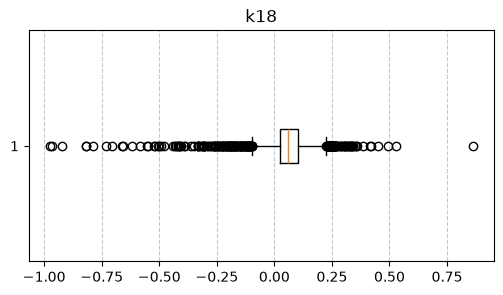

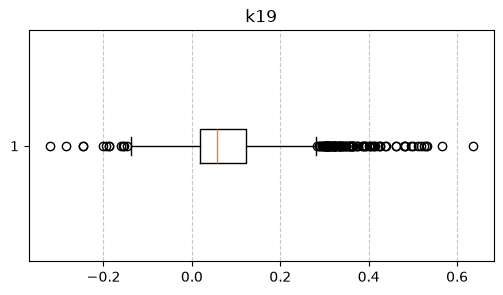

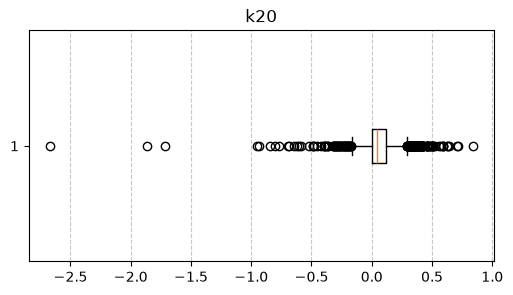

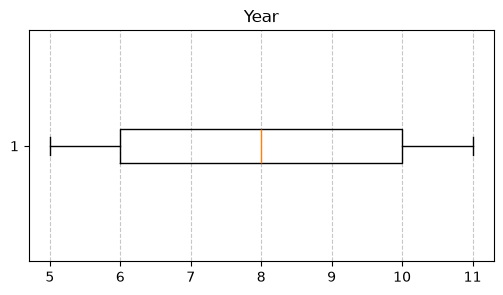

In [51]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), orientation='horizontal')
    plt.title(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

Cреднеспис.числ.работн: 9.39% 253
k1: 7.24% 195
k2: 17.25% 465
k3: 7.24% 195
k4: 2.67% 72
k4_new: 0.56% 15
k5: 0.00% 0
k6: 0.00% 0
k7: 9.20% 248
k8: 0.00% 0
k9: 4.97% 134
k10: 4.34% 117
k11: 3.53% 95
k12: 11.58% 312
k13: 0.30% 8
k14: 1.52% 41
k15: 4.19% 113
k16: 8.91% 240
k17: 13.21% 356
k18: 4.04% 109
k19: 2.37% 64
k20: 5.68% 153
Year: 0.00% 0


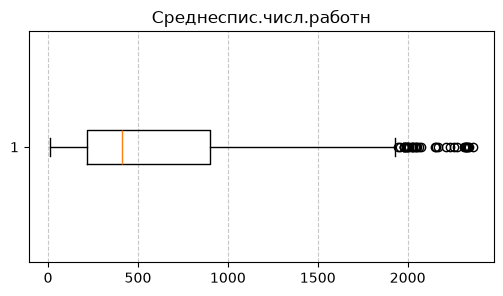

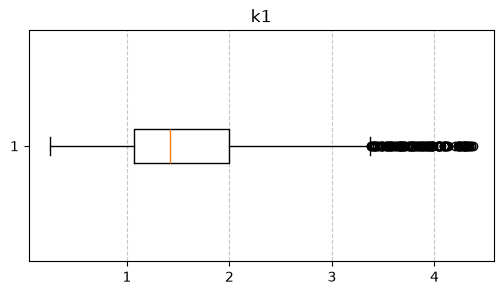

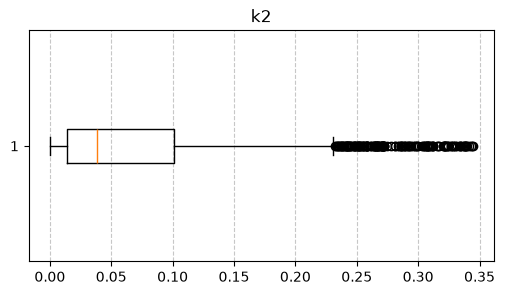

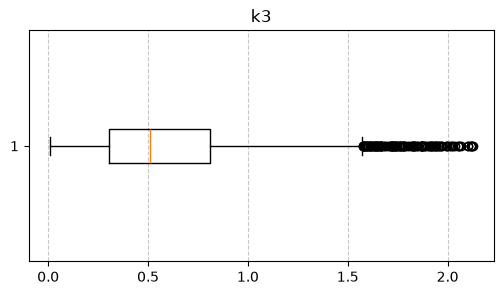

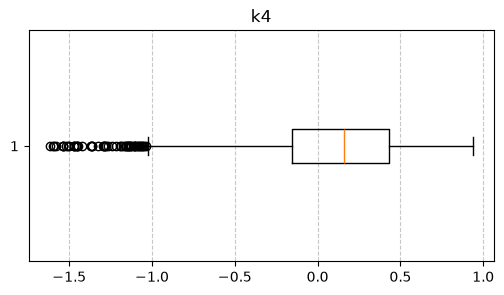

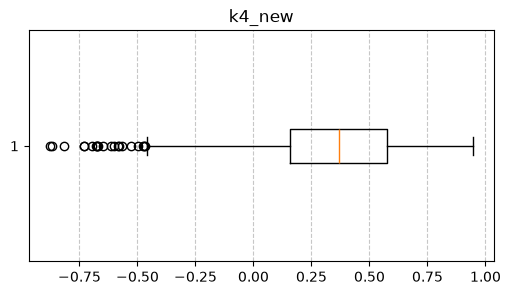

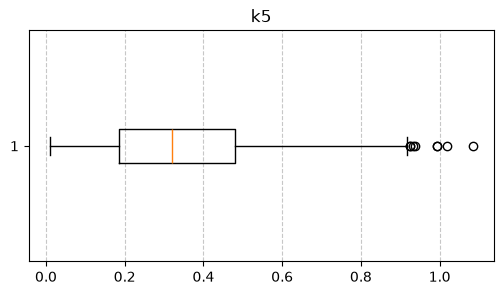

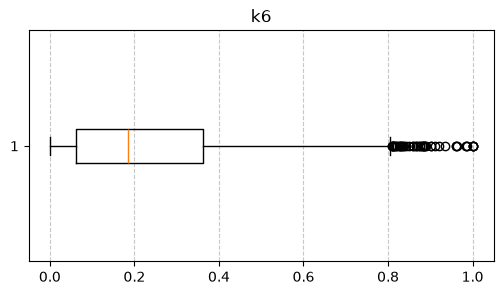

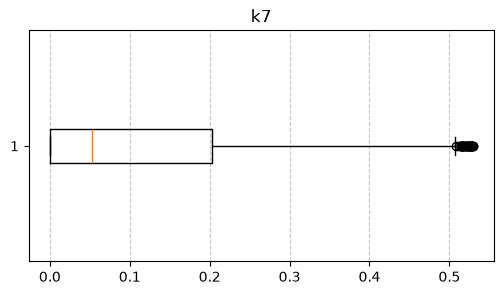

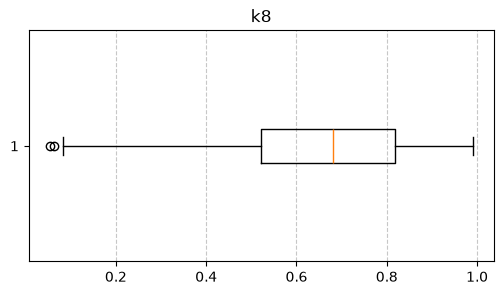

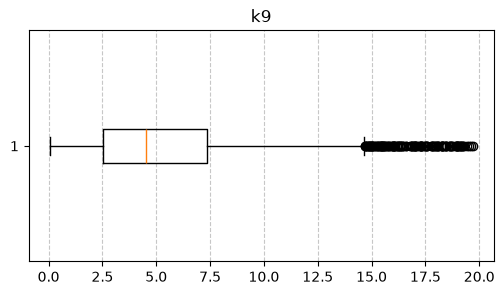

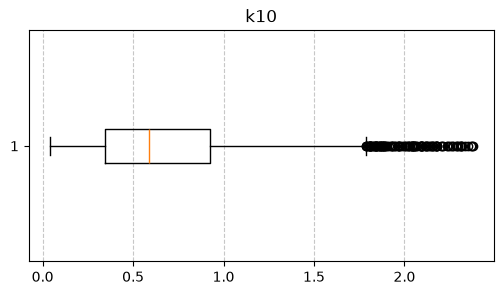

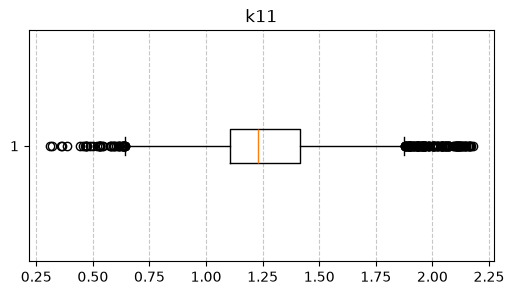

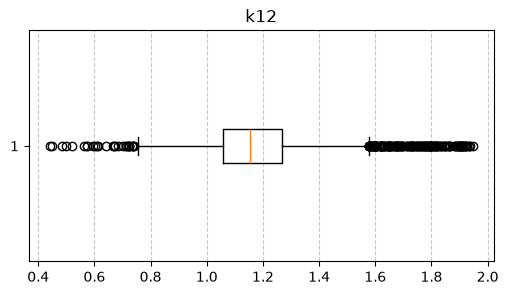

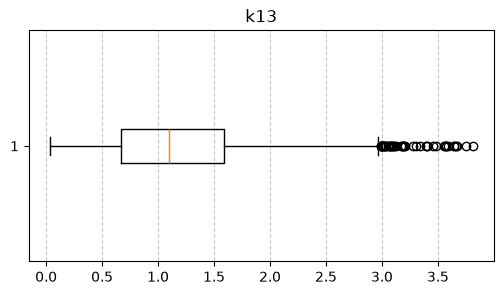

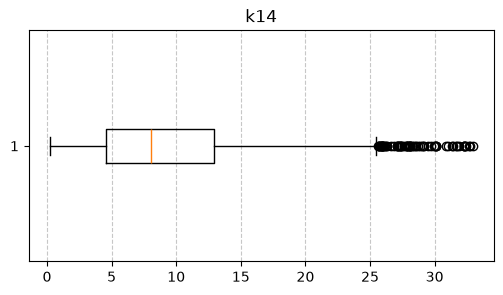

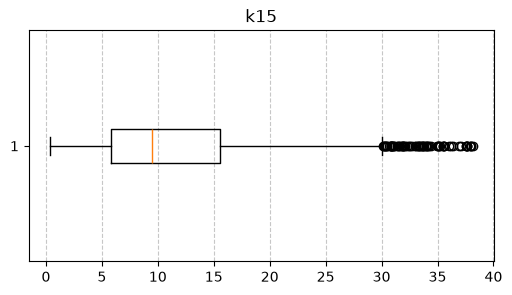

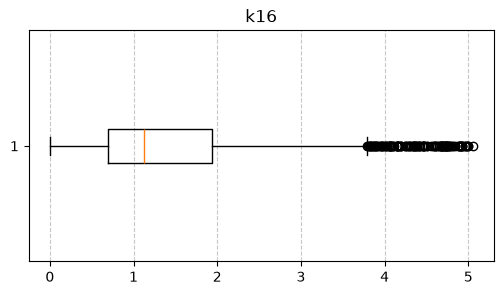

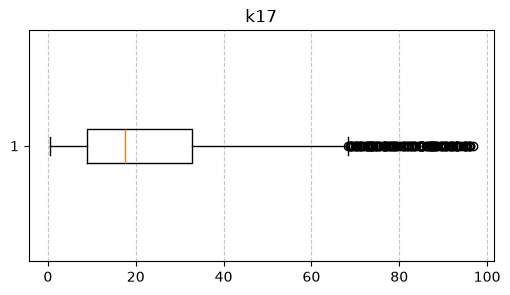

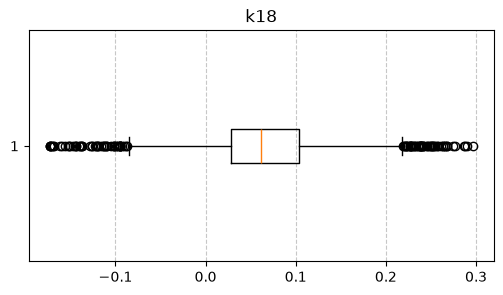

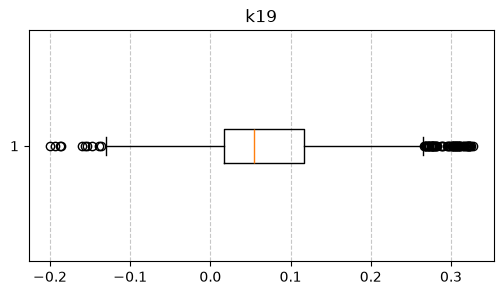

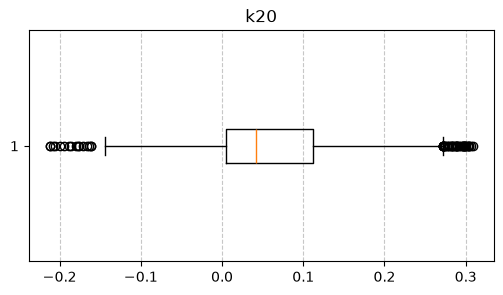

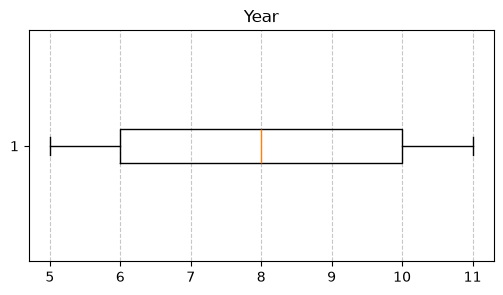

In [52]:
def hampel_test(data, mul=5.2):
    clean_data = data.dropna()
    med = data.median()
    mad = (data - med).abs().median()
    left_bound = med - mul * mad
    right_bound = med + mul * mad
    mask = (clean_data < left_bound) | (clean_data > right_bound)
    return mask.reindex(data.index, fill_value=False)

df_clean = df.copy()
for col in num_cols:
    mask = hampel_test(df[col], 6)
    perc = mask.mean() * 100
    count = mask.sum()
    print(f"{col}: {perc:.2f}% {count}")
    df_clean.loc[mask, col] = np.nan

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df_clean[col].dropna(), orientation='horizontal')
    plt.title(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

После удаления шума с помощью теста Хампеля получили более читаемы боксплоты, но все равно в них достаточно много объектов классифицируются как шумовые. Удалять их нельзя, потому что это приведет к сильному сокращению выборки

In [53]:
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
df_clean.describe()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2.442000e+03,2.500000e+03,2.230000e+03,2.500000e+03,2.623000e+03,1.525000e+03,2.695000e+03,2.695000e+03,2.447000e+03,2.695000e+03,...,2.383000e+03,2.687000e+03,2.654000e+03,2.582000e+03,2.455000e+03,2.339000e+03,2.586000e+03,2.631000e+03,2.542000e+03,2695.000000
mean,-8.147091e-17,6.821210e-17,-6.372581e-17,-1.136868e-17,-1.083557e-17,9.318593e-18,-1.160070e-16,-5.800349e-17,-2.322984e-17,-1.898296e-16,...,-4.532207e-16,-1.480848e-16,1.338626e-17,8.806107e-17,-9.840510e-17,6.683172e-17,-2.033262e-16,-9.722364e-17,-8.385634e-17,0.000000
std,1.000205e+00,1.000200e+00,1.000224e+00,1.000200e+00,1.000191e+00,1.000328e+00,1.000186e+00,1.000186e+00,1.000204e+00,1.000186e+00,...,1.000210e+00,1.000186e+00,1.000188e+00,1.000194e+00,1.000204e+00,1.000214e+00,1.000193e+00,1.000190e+00,1.000197e+00,1.000186
min,-1.191166e+00,-1.689256e+00,-8.864594e-01,-1.403676e+00,-3.754202e+00,-3.978089e+00,-1.699168e+00,-1.117230e+00,-8.266147e-01,-3.076549e+00,...,-3.498259e+00,-1.701272e+00,-1.425926e+00,-1.485003e+00,-1.371150e+00,-1.140251e+00,-3.585934e+00,-3.433153e+00,-3.324946e+00,-1.500000
25%,-7.717735e-01,-6.892435e-01,-7.177017e-01,-7.196982e-01,-5.667196e-01,-6.296962e-01,-8.140866e-01,-8.218504e-01,-8.266147e-01,-6.830136e-01,...,-6.040141e-01,-7.632770e-01,-7.566275e-01,-7.551164e-01,-7.216992e-01,-7.336550e-01,-5.737292e-01,-6.989999e-01,-7.027515e-01,-1.000000
50%,-3.797327e-01,-2.592267e-01,-4.155026e-01,-2.601194e-01,1.175088e-01,5.358050e-02,-1.334687e-01,-2.480376e-01,-4.628421e-01,1.324537e-01,...,-1.524844e-01,-1.329916e-01,-2.201917e-01,-2.740241e-01,-3.199473e-01,-3.246133e-01,-6.497541e-02,-2.301455e-01,-2.564616e-01,0.000000
75%,6.175908e-01,4.425846e-01,3.601542e-01,4.384717e-01,7.062472e-01,7.122481e-01,6.738908e-01,5.780298e-01,5.728380e-01,8.238722e-01,...,3.672490e-01,5.827306e-01,5.360605e-01,5.341472e-01,4.404616e-01,3.983648e-01,5.718717e-01,5.560276e-01,5.880542e-01,1.000000
max,3.572079e+00,3.354115e+00,3.371754e+00,3.445432e+00,1.806720e+00,1.909049e+00,3.724643e+00,3.576410e+00,2.825452e+00,1.706832e+00,...,3.552352e+00,3.841443e+00,3.629659e+00,3.539553e+00,3.362442e+00,3.445536e+00,3.457723e+00,3.208742e+00,2.971888e+00,1.500000


После масштабирования имеем среднее 0 и дисперсию 1

# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

ЗАДАЧИ ИССЛЕДОВАНИЯ:
1. Получить матрицу парных коэффициентов корреляции для всех имеющихся
показателей.
2. Выявить переменные, имеющие наиболее тесные взаимосвязи, а также
проанализировать знаки показателей корреляции.
3. Выделить переменные, которые возможно исключить из дальнейшего анализа в
силу существования тесной связи с другой/ими переменной/ыми.

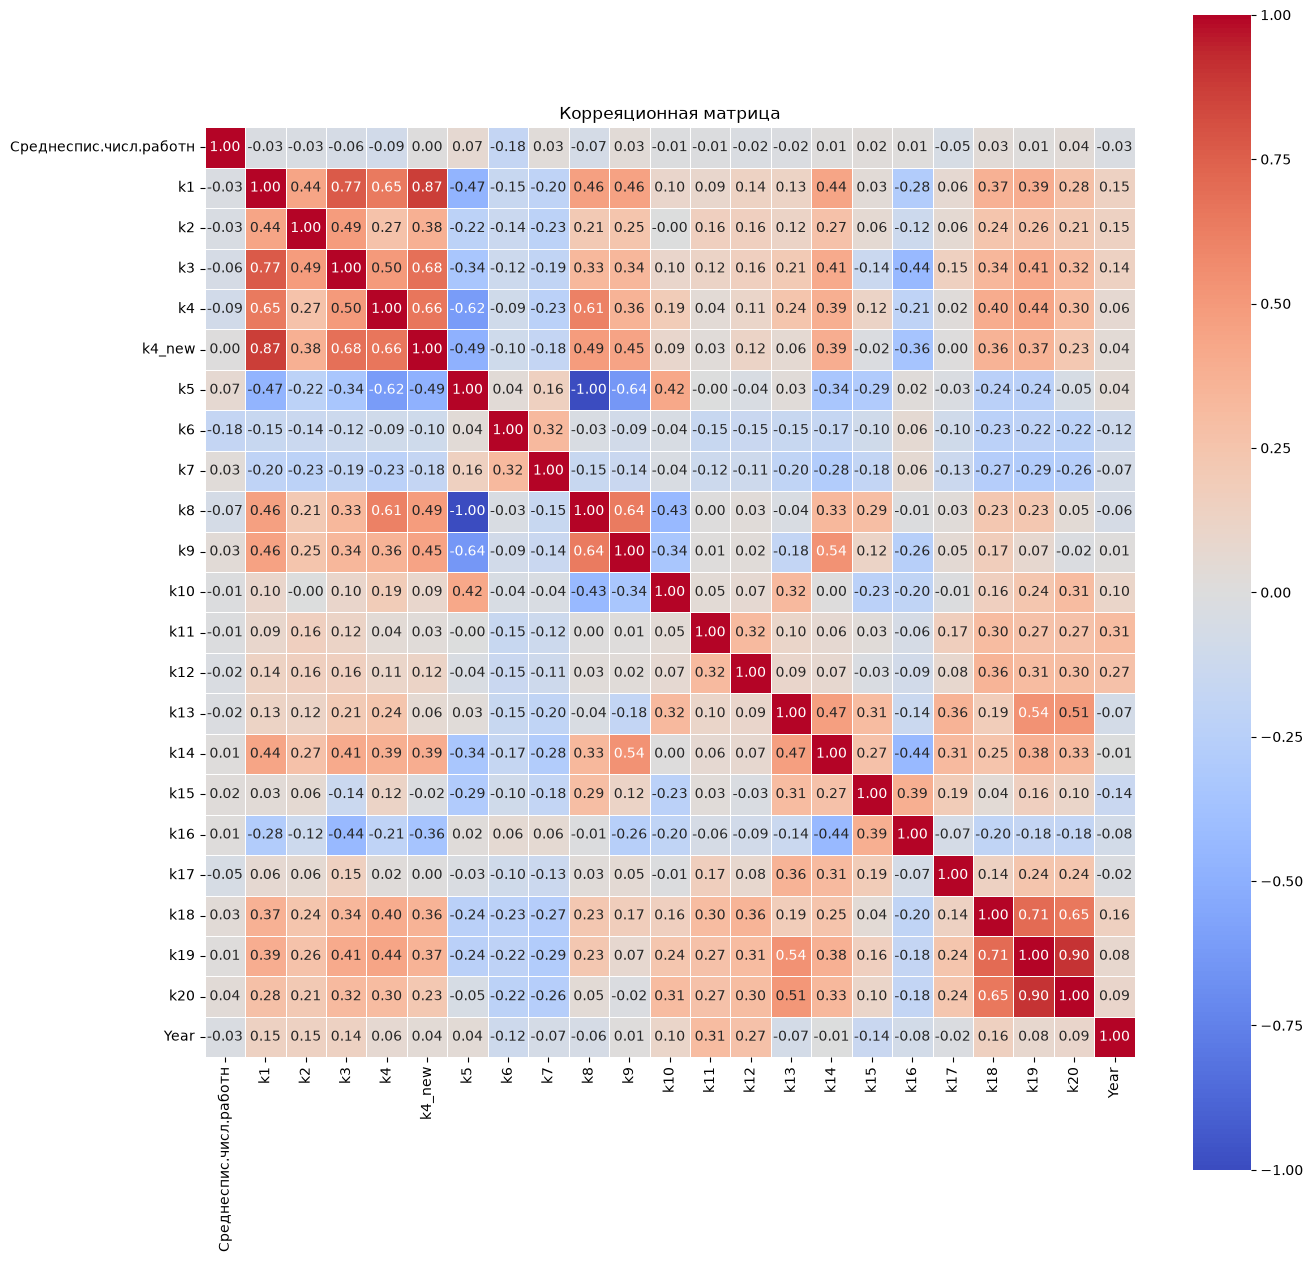

In [55]:
corr_matrix = df_clean[num_cols].corr()
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.4,
    square=True     
)
plt.title('Корреяционная матрица')
plt.show()

высокие корреляции у признаков К19-К20, К1-К4_new, и полная линейная зависимость у K5-K8